In [1]:
!pip install rouge-score bert-score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nv

In [3]:
import pandas as pd
from rouge_score import rouge_scorer
from bert_score import score
import matplotlib.pyplot as plt


In [4]:
# CHANGE THIS PATH ACCORDING TO YOUR UPLOADED FILE
df = pd.read_csv("/kaggle/input/pre-train/gemma_pre_train.csv")

df.head()


,Context,Response,Predicted_Response
0,"I get so much anxiety, and I don’t know why. I...",The are two ways that such anxiety can be deal...,"Hey there, thank you for sharing this with me...."
1,I think about death all the time because I fee...,Feeling alone and/or isolated is almost always...,"Oh, I can completely understand how you're fee..."
2,I am not sure if I am depressed. I don't know ...,"You are not alone, many people fear opening up...",Sorry to hear that you're struggling with this...
3,I'm in a long-distance relationship with my id...,The basic guideline for relationship satisfact...,Thank you for sharing your concerns with me. I...
4,I am divorced and happily remarried. Our blend...,It sounds really difficult to know that your d...,Thank you for sharing this difficult situation...


In [7]:
df.columns.tolist()


['Context', 'Response', 'Predicted_Response']

In [8]:
references = df["Response"].fillna("").astype(str).tolist()
predictions = df["Predicted_Response"].fillna("").astype(str).tolist()


In [9]:
scorer = rouge_scorer.RougeScorer(
    ['rouge1','rouge2','rougeL','rougeLsum'], 
    use_stemmer=True
)

r1 = r2 = rL = rLsum = 0

for ref, pred in zip(references, predictions):
    scores = scorer.score(ref, pred)
    r1 += scores['rouge1'].fmeasure
    r2 += scores['rouge2'].fmeasure
    rL += scores['rougeL'].fmeasure
    rLsum += scores['rougeLsum'].fmeasure

n = len(references)

rouge_results = {
    "ROUGE-1": r1/n,
    "ROUGE-2": r2/n,
    "ROUGE-L": rL/n,
    "ROUGE-Lsum": rLsum/n
}

print("ROUGE Scores:")
rouge_results


ROUGE Scores:


{'ROUGE-1': 0.3039068579857419,
 'ROUGE-2': 0.05034800849516726,
 'ROUGE-L': 0.1470807727060164,
 'ROUGE-Lsum': 0.19086916627190806}

In [10]:
P, R, F1 = score(predictions, references, lang="en", verbose=True)
bert_f1 = float(F1.mean())

print("BERTScore F1:", bert_f1)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/7 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/4 [00:00<?, ?it/s]

done in 11.72 seconds, 17.92 sentences/sec
BERTScore F1: 0.835552453994751


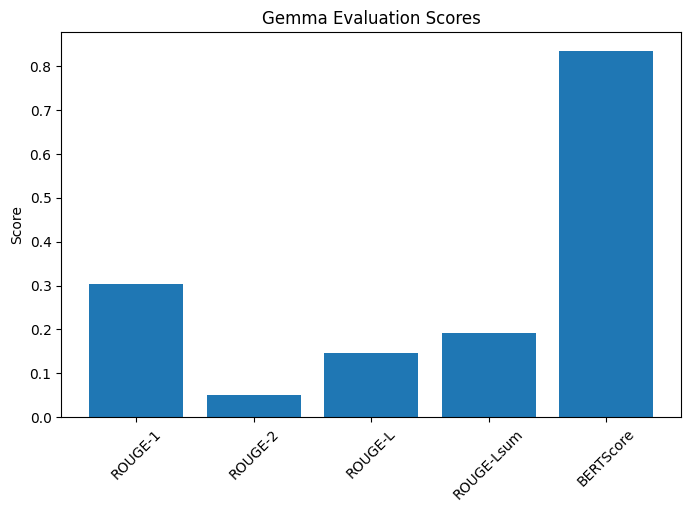

In [11]:
# Prepare data for plot
metrics = list(rouge_results.keys()) + ["BERTScore"]
values = list(rouge_results.values()) + [bert_f1]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)
plt.title("Gemma Evaluation Scores")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()
